In [4]:
import pandas as pd
df = pd.read_csv('/Sales Transaction v.4a.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [6]:
df

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany


# **Data cleaning and preparation**

In [7]:
df.isnull().sum()

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,0
Quantity,0
CustomerNo,55
Country,0


In [8]:
df = df.convert_dtypes()

In [9]:
df.describe()

,Price,Quantity,CustomerNo
count,536350.0,536350.0,536295.0
mean,12.662182,9.919347,15227.893178
std,8.49045,216.6623,1716.582932
min,5.13,-80995.0,12004.0
25%,10.99,1.0,13807.0
50%,11.94,3.0,15152.0
75%,14.09,10.0,16729.0
max,660.62,80995.0,18287.0


In [10]:
df.describe(include=('string'))

,TransactionNo,Date,ProductNo,ProductName,Country
count,536350,536350,536350,536350,536350
unique,23204,305,3768,3768,38
top,573585,12/5/2019,85123A,Cream Hanging Heart T-Light Holder,United Kingdom
freq,1111,5299,2378,2378,485095


In [11]:
df['CustomerNo'] = df['CustomerNo'].fillna(0)

In [12]:
df.isnull().sum()

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Price,0
Quantity,0
CustomerNo,0
Country,0


In [13]:
df['Date']= pd.to_datetime(df['Date'], errors = 'coerce')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  536350 non-null  string        
 1   Date           536350 non-null  datetime64[ns]
 2   ProductNo      536350 non-null  string        
 3   ProductName    536350 non-null  string        
 4   Price          536350 non-null  Float64       
 5   Quantity       536350 non-null  Int64         
 6   CustomerNo     536350 non-null  Int64         
 7   Country        536350 non-null  string        
dtypes: Float64(1), Int64(2), datetime64[ns](1), string(4)
memory usage: 34.3 MB


In [15]:
df['TransactionNo'].str.contains('[A-Za-z]', na=False)

,TransactionNo
0,False
1,False
2,False
3,False
4,False
...,...
536345,True
536346,True
536347,True
536348,True


In [16]:
df.loc[536345]


,536345
TransactionNo,C536548
Date,2018-12-01 00:00:00
ProductNo,22168
ProductName,Organiser Wood Antique White
Price,18.96
Quantity,-2
CustomerNo,12472
Country,Germany


# **Exploratory Data Analysis (EDA)**

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Revenue'] = df['Quantity'] * df['Price']

**Revenue by month**

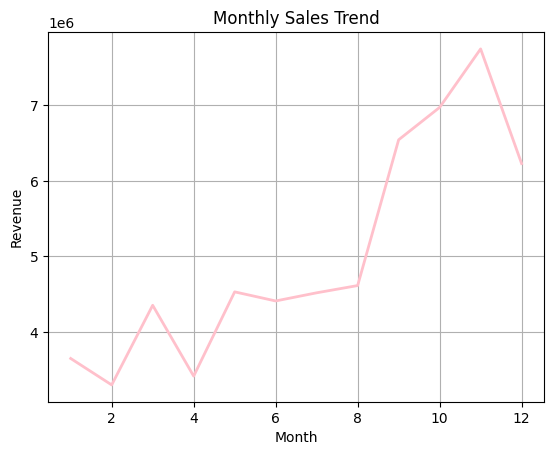

In [21]:
monthly_sales = df.groupby('Month')['Revenue'].sum().reset_index()
plt.plot(monthly_sales['Month'], monthly_sales['Revenue'],
         linewidth = 2,
         color = 'pink')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

**Top 10 Most Purchased Products**

In [22]:
top_products = df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

ProductName
Popcorn Holder                        56450
World War 2 Gliders Asstd Designs     53847
Jumbo Bag Red Retrospot               47363
Assorted Colour Bird Ornament         36445
Pack Of 72 Retrospot Cake Cases       36231
Cream Hanging Heart T-Light Holder    35378
Rabbit Night Light                    30680
Mini Paint Set Vintage                26437
Pack Of 12 London Tissues             25907
Pack Of 60 Pink Paisley Cake Cases    24753
Name: Quantity, dtype: Int64


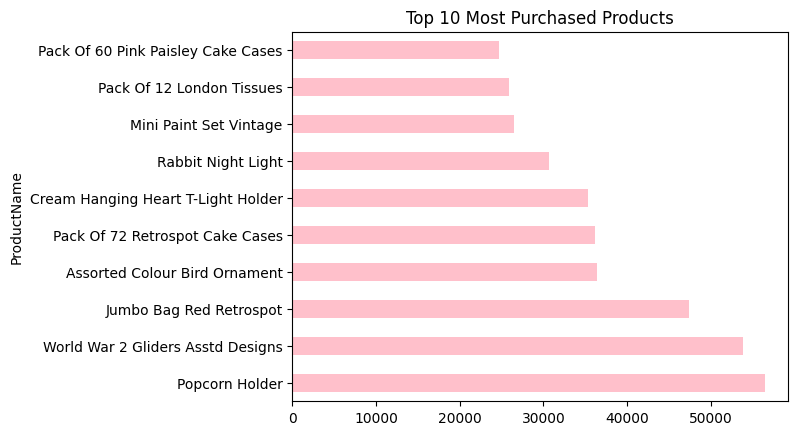

In [23]:
top_products.plot(kind='barh', color = 'pink') #bar or barh(hoán đổi X <-> y)
plt.title('Top 10 Most Purchased Products')
plt.show()

**Products per Transaction**

In [25]:
product_per_transaction = df.groupby('TransactionNo')['Quantity'].sum()
print(product_per_transaction)

TransactionNo
536365         40
536366         12
536367         83
536368         15
536369          3
            ...  
C581470        -4
C581484    -80995
C581490       -23
C581568        -5
C581569        -6
Name: Quantity, Length: 23204, dtype: Int64


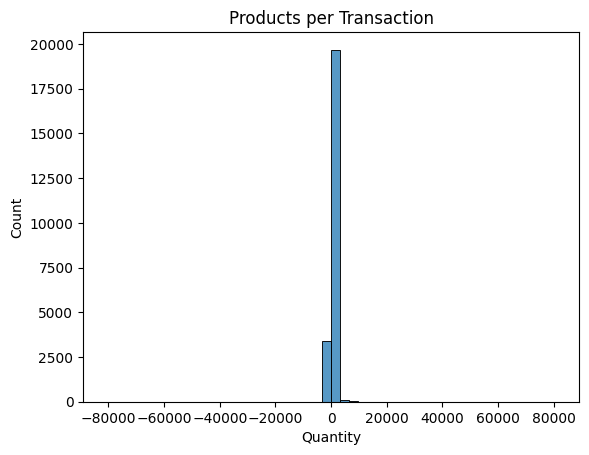

In [27]:
sns.histplot(product_per_transaction, bins=50)
plt.title('Products per Transaction')
plt.show()

**Profit by Country**

In [28]:
profit_by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending = True).head(10)
print(profit_by_country)

Country
Saudi Arabia              903.15
Bahrain                  3226.86
RSA                      4259.83
Brazil                   4652.27
Lebanon                  5692.32
European Community       6181.01
Czech Republic            6756.8
Lithuania                8188.08
Greece                   9666.53
United Arab Emirates    11966.26
Name: Revenue, dtype: Float64


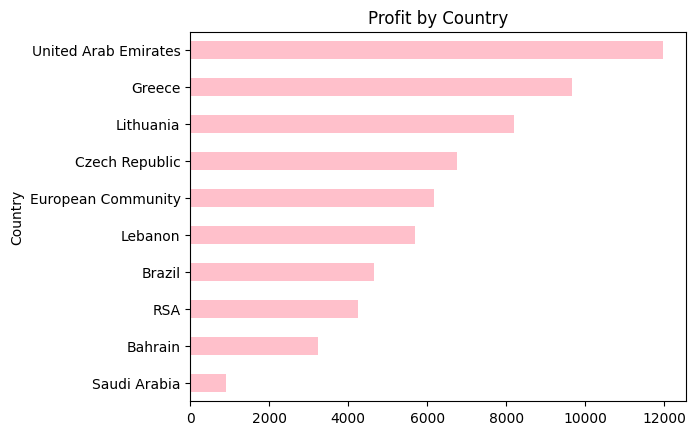

In [29]:
profit_by_country.plot(kind='barh', color = 'pink')
plt.title('Profit by Country')
plt.show()

**Top 10 highest-spending customers**

In [31]:
top_customers = df.groupby('CustomerNo')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerNo
14646    2108959.95
18102     897137.36
12415     895267.24
17450     876816.01
14911      873037.9
14156     683869.28
14298     634173.99
13694     630949.58
17511     627685.41
16684     518976.78
Name: Revenue, dtype: Float64


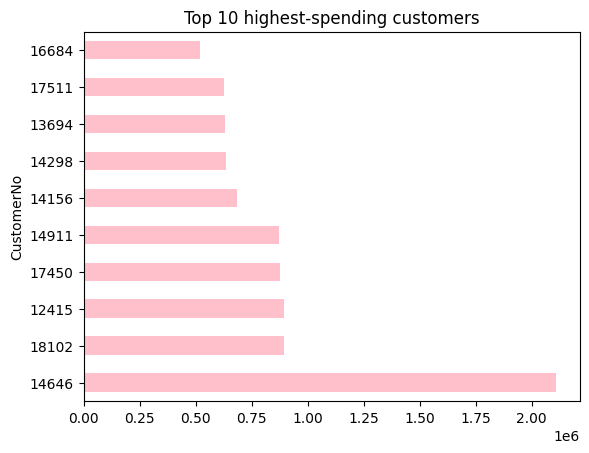

In [35]:
top_customers.plot(kind='barh', color = 'pink')
plt.title('Top 10 highest-spending customers')
plt.show()